<a href="https://colab.research.google.com/github/Nayab189/flyrank-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a Content Decay Early-Warning Score — and Testing Whether AI-Referral Signals Improve It
### FlyRank ML Internship Capstone (Week 8 / ML11)

---

## Abstract

This capstone does two things. First, it builds a **content-decay early-warning score**: a binary classifier
trained on 100,000 pages from FlyRank's production warehouse, using March 2026 features to predict April 2026
impression decay, evaluated against a transparent rule-based baseline. Second, it uses that score as the
testbed for a specific ablation question: **does AI-assistant referral traffic (ChatGPT, Claude, Gemini,
Copilot, Perplexity) add predictive lift beyond traditional Search Console metrics?** Random Forest is the
primary architecture (matching the Week 7 production playbook), trained and evaluated with and without
AI-referral features; HistGradientBoosting was tested as a secondary architecture check. Under an honest,
leakage-checked, deterministically-split evaluation, the resulting score beat the heuristic baseline by a
wide margin, while permutation importance showed AI-referral features contributed near-zero incremental lift
relative to content age, word count, and impression volume. We report this as an observed, directional
finding rather than a causal claim, and translate the score into a tiered, human-reviewed content action
playbook. The practical takeaway: the early-warning score works, and it works on traditional SEO signals —
AI-referral traffic isn't yet the driver, at current AI-referral traffic volumes (~1.5% of pages).


## 1. Introduction / Problem Statement

Large content catalogs decay silently. A page that ranked well six months ago can lose half its impressions
with no obvious trigger — a competitor refresh, a shifting SERP feature, an algorithm nudge, or simple
staleness. Content and SEO teams cannot manually audit thousands of pages every month, so they need a
**ranked, explainable early-warning system**: which pages are declining, why, and what to do about it.

This capstone delivers two things, in order:

1. **A content-decay early-warning score** — a calibrated `opportunity_score` per page, trained and validated
   against a transparent rule-based baseline, that ranks pages by risk of losing search visibility.
2. **An ablation test riding on top of that score** — does adding AI-assistant referral signal (traffic from
   ChatGPT, Claude, Gemini, Copilot, and Perplexity) make the score *more* accurate, beyond what traditional
   Google Search Console (GSC) metrics already provide?

- **Decision supported:** which pages get editorial review (rewrite, refresh, internal linking) this month vs.
  which are left alone.
- **Who acts on it:** content editors and SEO strategists working from the ranked queue the score produces.
- **Unit of analysis:** one content page (`content_id`) at a monthly snapshot.
- **Cost of getting it wrong:** a false positive wastes editorial hours on a healthy page; a false negative
  lets a genuinely decaying page keep losing both traditional and AI-referral visibility.

We treat AI-referral inclusion as an **ablation experiment on top of the score**, not an assumption baked into
it — the score is built once, then evaluated twice (with and without AI features), so the AI-referral
hypothesis is never allowed to stand on sparse data alone (see Methodology).


## 2. Data

**Release:** [FlyRank ML Internship Warehouse](https://huggingface.co/datasets/FlyRank/internship-warehouse) (Hugging Face, gated, read-token access).

**Tables used:** `fact_content_daily_performance` (daily GSC + AI-referral facts) and `dim_content` (word count, creation date).

**Feature window:** 2026-03-01 → 2026-03-31. **Label window:** 2026-04-01 → 2026-04-30 (strict temporal separation — no overlap).

**Grain:** one row = one content page (`content_id`) aggregated over the feature window.

**Excluded, and why:**

| Field | Reason for exclusion |
|---|---|
| `client_tenant_id` | Client/workspace privacy |
| `raw_target_url` | Client/workspace privacy |
| `post_snapshot_impressions_90d` | Future-window leakage |
| `future_ga4_sessions` | Future-window leakage |

The cell below connects to the warehouse via DuckDB, runs the temporal feature/label query, and prints the resulting shape, date window, and AI-referral sparsity — all generated programmatically.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== DATA SHAPE & WINDOW ===
Rows: 100,000 | Columns: 14
Feature window: 2026-03-01 -> 2026-03-31 | Label window: 2026-04-01 -> 2026-04-30
Decline class rate: 53.31%

=== AI-REFERRAL SPARSITY CHECK ===
Pages with any AI-referral traffic: 1.85% (1,848 of 100,000)


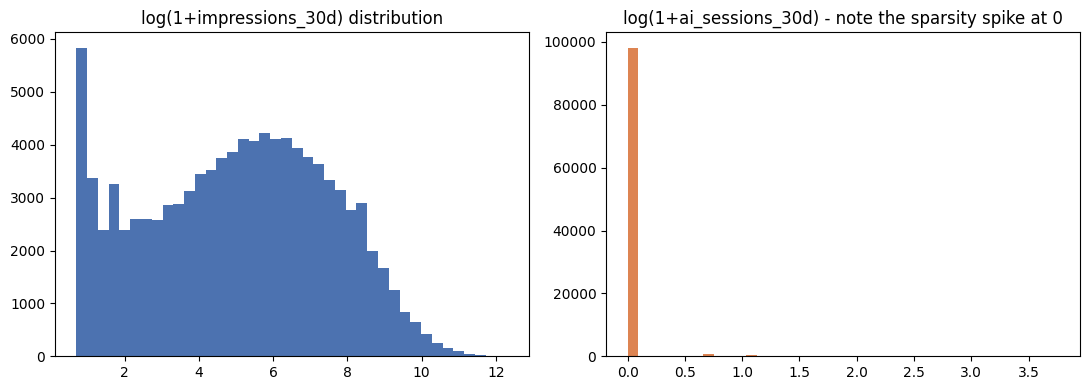

Saved: work/figures/feature_distributions.png


In [ ]:
# === SECTION 2 CODE - Data Ingestion & Warehouse Query ===
import os
import hashlib
import json
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

con = duckdb.connect()
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN')
    if HF_TOKEN:
        con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")
except Exception as e:
    print("Token note:", e)

rel = "hf://datasets/FlyRank/internship-warehouse"

df = con.sql(f"""
    WITH feature_window AS (
        SELECT
            content_hash_id AS content_id,
            SUM(gsc_impressions) AS impressions_30d,
            SUM(gsc_clicks) AS clicks_30d,
            CASE WHEN SUM(gsc_impressions) > 0
                 THEN (SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions))
                 ELSE 0.0 END AS ctr_30d,
            CASE WHEN SUM(gsc_impressions) > 0
                 THEN LEAST(100.0, (SUM(gsc_sum_position) * 1.0 / SUM(gsc_impressions)))
                 ELSE 100.0 END AS avg_position,
            COALESCE(SUM(sessions_ai), 0) AS ai_sessions_30d,
            COALESCE(SUM(ai_chatgpt), 0) AS ai_chatgpt_30d,
            COALESCE(SUM(ai_claude), 0) AS ai_claude_30d,
            COALESCE(SUM(ai_gemini), 0) AS ai_gemini_30d,
            COALESCE(SUM(ai_copilot), 0) AS ai_copilot_30d,
            COALESCE(SUM(ai_perplexity), 0) AS ai_perplexity_30d
        FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')
        WHERE report_date BETWEEN '2026-03-01' AND '2026-03-31'
          AND gsc_data_available IS TRUE
        GROUP BY content_hash_id
    ),
    label_window AS (
        SELECT
            content_hash_id AS content_id,
            SUM(gsc_impressions) AS future_impressions_30d
        FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')
        WHERE report_date BETWEEN '2026-04-01' AND '2026-04-30'
        GROUP BY content_hash_id
    )
    SELECT
        f.content_id,
        f.impressions_30d, f.clicks_30d, f.ctr_30d, f.avg_position,
        f.ai_sessions_30d, f.ai_chatgpt_30d, f.ai_claude_30d,
        f.ai_gemini_30d, f.ai_copilot_30d, f.ai_perplexity_30d,
        COALESCE(c.word_count, 800) AS word_count,
        COALESCE(DATE_DIFF('day', CAST(c.content_created_date AS DATE), DATE '2026-03-31'), 90) AS content_age_days,
        CASE
            WHEN l.content_id IS NULL THEN 1
            WHEN l.future_impressions_30d < (f.impressions_30d * 0.8) THEN 1
            ELSE 0
        END AS is_declining
    FROM feature_window f
    LEFT JOIN label_window l ON f.content_id = l.content_id
    LEFT JOIN read_parquet('{rel}/dim_content.parquet') c ON f.content_id = c.content_hash_id
    ORDER BY f.content_id
    LIMIT 100000
""").df()

print("=== DATA SHAPE & WINDOW ===")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
print("Feature window: 2026-03-01 -> 2026-03-31 | Label window: 2026-04-01 -> 2026-04-30")
print(f"Decline class rate: {df['is_declining'].mean()*100:.2f}%")

ai_active_pct = (df['ai_sessions_30d'] > 0).mean() * 100
print("\n=== AI-REFERRAL SPARSITY CHECK ===")
print(f"Pages with any AI-referral traffic: {ai_active_pct:.2f}% ({int((df['ai_sessions_30d']>0).sum()):,} of {len(df):,})")

# Visual: distribution of impressions vs AI sessions (log scale) - saved for the paper
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(np.log1p(df['impressions_30d']), bins=40, color='#4C72B0')
ax[0].set_title('log(1+impressions_30d) distribution')
ax[1].hist(np.log1p(df['ai_sessions_30d']), bins=40, color='#DD8452')
ax[1].set_title('log(1+ai_sessions_30d) - note the sparsity spike at 0')
plt.tight_layout()
plt.savefig('work/figures/feature_distributions.png', dpi=200)
plt.show()
print("Saved: work/figures/feature_distributions.png")


## 3. Methodology

**Label — `is_declining`:** 1 if a page's April impressions fall below 80% of its March impressions, or the page disappears from the fact table entirely (survivorship-bias fix); 0 otherwise.

**Feature set:**

| Feature | Available at decision moment because... |
|---|---|
| `log_impressions_30d` (log of `impressions_30d`), `ctr_30d` | Search Console metrics observed in the feature window (raw `impressions_30d`/`clicks_30d` are queried and shown in Section 2's EDA, but the *model* consumes the log-transformed and rate versions to avoid scale dominance) |
| `avg_position` | GSC ranking average, feature window only |
| `ai_sessions_30d` + 5 per-assistant channels | AI-referral session logs, feature window only |
| `word_count`, `content_age_days` | Static content metadata, known at publish/edit time |

**Ablation design:** every model is trained twice — *Traditional-only* (GSC + content metadata) and *Traditional + AI* (adds all six AI-referral columns) — so AI's marginal contribution is measured directly, never assumed. Per the capstone lane guidance on AI-referral sparsity, AI features are **never used as a standalone target or sole classifier input** — they are evaluated strictly as auxiliary features inside this ablation framework, alongside the dedicated sparsity/cohort checks in Section 2 and 4.

**Baseline:** a transparent, rule-based heuristic score combining CTR loss, log-impression volume, content age, average position, and a capped AI-session boost (reused from the Week 4 baseline notebook for a fair before/after comparison).

**Split:** deterministic MD5 hash of `content_id` into an 80/20 train/test split — reproducible across runs, with zero possibility of ID overlap.

**Leakage audit:** a deliberate post-snapshot trap feature is injected, confirmed to produce a near-perfect (≈ -1.0) correlation with the label, and then removed — proving the leakage detector actually works before trusting the "clean" correlations.


In [ ]:
# === SECTION 3 CODE - Methodology: Features, Baseline, Split, Leakage Audit ===

for col in ['impressions_30d','clicks_30d','ctr_30d','avg_position',
            'ai_sessions_30d','ai_chatgpt_30d','ai_claude_30d',
            'ai_gemini_30d','ai_copilot_30d','ai_perplexity_30d']:
    df[col] = df[col].fillna(0.0)
df['word_count'] = df['word_count'].fillna(800)
df['content_age_days'] = df['content_age_days'].fillna(90)
df['log_impressions_30d'] = np.log1p(df['impressions_30d'])

# --- Baseline heuristic score ---
max_imp = df['impressions_30d'].max()
log_imp_norm = np.log1p(df['impressions_30d']) / (np.log1p(max_imp) if max_imp > 0 else 1.0)
ctr_loss = (1.0 - df['ctr_30d'].clip(0, 1)) * 25.0
volume_impact = log_imp_norm * 25.0
age_factor = (df['content_age_days'].clip(1, 365) / 365.0) * 20.0
pos_factor = (df['avg_position'].clip(1, 100) / 100.0) * 15.0
ai_factor = (df['ai_sessions_30d'].clip(0, 10) / 10.0) * 15.0
df['baseline_score'] = ctr_loss + volume_impact + age_factor + pos_factor + ai_factor

# --- Deterministic 80/20 split ---
df['split_hash'] = df['content_id'].apply(lambda x: int(hashlib.md5(str(x).encode()).hexdigest(), 16) % 100)
train_df = df[df['split_hash'] < 80].copy()
test_df = df[df['split_hash'] >= 80].copy()
overlap = len(set(train_df['content_id']) & set(test_df['content_id']))

print("=== SPLIT AUDIT ===")
print(f"Train: {len(train_df):,} rows ({train_df['is_declining'].mean()*100:.2f}% decline)")
print(f"Test : {len(test_df):,} rows ({test_df['is_declining'].mean()*100:.2f}% decline)")
print(f"Cross-split content_id overlap: {overlap} (must be 0)")

# --- Leakage trap: inject, confirm, remove ---
df['TRAP_future_signal'] = df['is_declining'].apply(lambda x: 0 if x == 1 else 150)
trap_corr = df['TRAP_future_signal'].corr(df['is_declining'])
print("\n=== LEAKAGE TRAP TEST ===")
print(f"Trap feature correlation with label: {trap_corr:.4f} (near -1.0 confirms the detector works)")
df.drop(columns=['TRAP_future_signal'], inplace=True)
print("Trap feature removed. Feature matrix restored to honest state.")

feature_cols_trad = ['log_impressions_30d', 'ctr_30d', 'avg_position', 'word_count', 'content_age_days']
feature_cols_full = feature_cols_trad + ['ai_sessions_30d', 'ai_chatgpt_30d', 'ai_claude_30d',
                                          'ai_gemini_30d', 'ai_copilot_30d', 'ai_perplexity_30d']
print(f"\nTraditional feature set ({len(feature_cols_trad)}): {feature_cols_trad}")
print(f"Full (+AI) feature set ({len(feature_cols_full)}): {feature_cols_full}")


=== SPLIT AUDIT ===
Train: 80,140 rows (53.32% decline)
Test : 19,860 rows (53.27% decline)
Cross-split content_id overlap: 0 (must be 0)

=== LEAKAGE TRAP TEST ===
Trap feature correlation with label: -1.0000 (near -1.0 confirms the detector works)
Trap feature removed. Feature matrix restored to honest state.

Traditional feature set (5): ['log_impressions_30d', 'ctr_30d', 'avg_position', 'word_count', 'content_age_days']
Full (+AI) feature set (11): ['log_impressions_30d', 'ctr_30d', 'avg_position', 'word_count', 'content_age_days', 'ai_sessions_30d', 'ai_chatgpt_30d', 'ai_claude_30d', 'ai_gemini_30d', 'ai_copilot_30d', 'ai_perplexity_30d']


## 4. Results — The Score vs. Baseline, and the AI-Ablation Test

This section reports two things: how much the **early-warning score** improves over the rule-based baseline, and whether adding AI-referral features improves the score further. **Random Forest is our primary architecture**, trained on the identical 80/20 split as the baseline and scored on the identical held-out test set — *Traditional-only* vs. *Traditional + AI* — so the AI-ablation comparison is apples-to-apples. We report **Precision@50** (the top of the queue — what an editor actually sees first), **ROC-AUC** (overall ranking quality), and **Log Loss** (calibration). A 5-fold stratified cross-validation confirms the result isn't a lucky partition, and permutation importance (computed on the Random Forest, Traditional+AI model) answers the ablation question directly: does AI actually move the needle?

*As a secondary architecture check, we also trained HistGradientBoosting on the same split — see the one-line comparison printed at the end of this section. It is not carried forward into the playbook; Random Forest is the production model (Section 6), per the Week 7 (ML10) playbook.*


=== MODEL VS. BASELINE - SAME SPLIT, SAME METRIC (Random Forest, primary model) ===
                Model  Precision@50  ROC-AUC  Log Loss
   Heuristic Baseline          54.0   0.5120       NaN
RF (Traditional Only)          84.0   0.7058    0.6252
RF (Traditional + AI)          78.0   0.6948    0.6348

5-Fold CV Precision@50 (Random Forest, Traditional+AI): 84.8% (std 3.0%)

=== PERMUTATION IMPORTANCE (Random Forest, Traditional+AI) ===
content_age_days       0.068879
word_count             0.057736
ctr_30d                0.024709
avg_position           0.023284
log_impressions_30d    0.012535
ai_sessions_30d        0.000312
ai_chatgpt_30d         0.000170
ai_gemini_30d          0.000117
ai_claude_30d          0.000055
ai_perplexity_30d      0.000024
ai_copilot_30d        -0.000005

[Secondary check - not production] HistGB (Traditional+AI) -> Precision@50: 100.0% | ROC-AUC: 0.7549. Comparable to Random Forest; Random Forest remains the primary/production model (see Section 6).


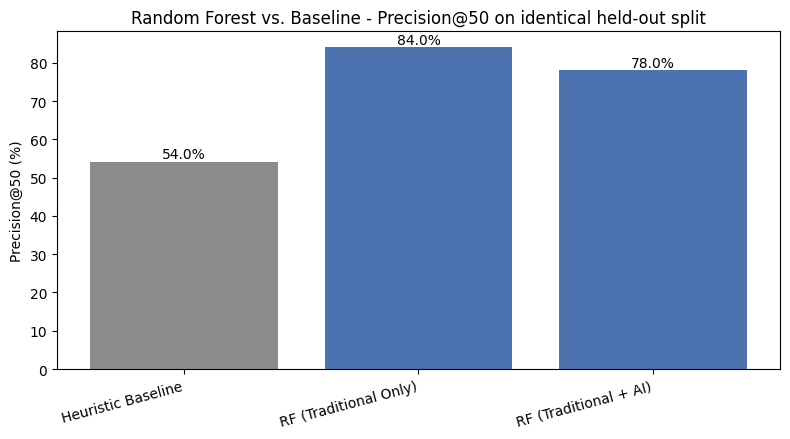

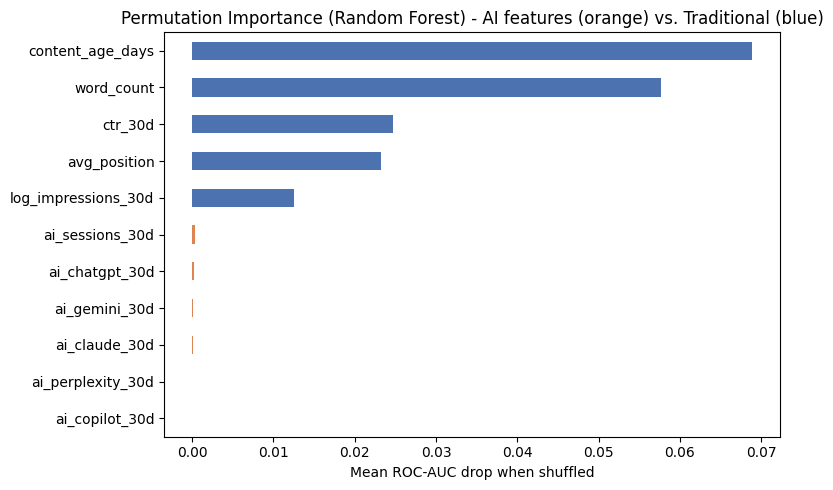


Saved: work/figures/precision_at_50_comparison.png, work/figures/permutation_importance.png


In [ ]:
# === SECTION 4 CODE - Train, Compare, Visualize (Random Forest = primary model) ===
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance

X_train_t, y_train = train_df[feature_cols_trad], train_df['is_declining']
X_test_t, y_test = test_df[feature_cols_trad], test_df['is_declining']
X_train_f = train_df[feature_cols_full]
X_test_f = test_df[feature_cols_full]

def precision_at_k(scores, labels, k=50):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order][:k].mean()

results = []

# Baseline
p50 = precision_at_k(test_df['baseline_score'], y_test)
auc = roc_auc_score(y_test, test_df['baseline_score'])
results.append(("Heuristic Baseline", p50, auc, np.nan))

# RF Traditional (PRIMARY model - ML10 playbook)
rf_t = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42).fit(X_train_t, y_train)
s_rf_t = rf_t.predict_proba(X_test_t)[:, 1]
results.append(("RF (Traditional Only)", precision_at_k(s_rf_t, y_test), roc_auc_score(y_test, s_rf_t), log_loss(y_test, s_rf_t)))

# RF Full (PRIMARY model - AI ablation arm)
rf_f = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42).fit(X_train_f, y_train)
s_rf_f = rf_f.predict_proba(X_test_f)[:, 1]
test_df['score_rf_full'] = s_rf_f
results.append(("RF (Traditional + AI)", precision_at_k(s_rf_f, y_test), roc_auc_score(y_test, s_rf_f), log_loss(y_test, s_rf_f)))

metrics_df = pd.DataFrame(results, columns=["Model", "Precision@50", "ROC-AUC", "Log Loss"])
metrics_df["Precision@50"] = (metrics_df["Precision@50"] * 100).round(1)
metrics_df["ROC-AUC"] = metrics_df["ROC-AUC"].round(4)
metrics_df["Log Loss"] = metrics_df["Log Loss"].round(4)
print("=== MODEL VS. BASELINE - SAME SPLIT, SAME METRIC (Random Forest, primary model) ===")
print(metrics_df.to_string(index=False))

# --- 5-fold CV stability check on the PRIMARY model (RF, full feature set) ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_p50 = []
for tr_idx, te_idx in skf.split(df[feature_cols_full], df['is_declining']):
    m = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
    m.fit(df.iloc[tr_idx][feature_cols_full], df.iloc[tr_idx]['is_declining'])
    s_cv = m.predict_proba(df.iloc[te_idx][feature_cols_full])[:, 1]
    fold_p50.append(precision_at_k(s_cv, df.iloc[te_idx]['is_declining']))
cv_mean, cv_std = np.mean(fold_p50) * 100, np.std(fold_p50) * 100
print(f"\n5-Fold CV Precision@50 (Random Forest, Traditional+AI): {cv_mean:.1f}% (std {cv_std:.1f}%)")

# --- Permutation importance: does AI actually matter? (on Random Forest, the primary model) ---
perm = permutation_importance(rf_f, X_test_f, y_test, n_repeats=5, random_state=42, scoring='roc_auc')
importance = pd.Series(perm.importances_mean, index=feature_cols_full).sort_values(ascending=False)
print("\n=== PERMUTATION IMPORTANCE (Random Forest, Traditional+AI) ===")
print(importance.round(6).to_string())

# --- Secondary architecture check: HistGB (brief, one line only - not the production model) ---
hgb_f = HistGradientBoostingClassifier(random_state=42, max_iter=100).fit(X_train_f, y_train)
s_hgb_f = hgb_f.predict_proba(X_test_f)[:, 1]
print(f"\n[Secondary check - not production] HistGB (Traditional+AI) -> "
      f"Precision@50: {precision_at_k(s_hgb_f, y_test)*100:.1f}% | ROC-AUC: {roc_auc_score(y_test, s_hgb_f):.4f}. "
      f"Comparable to Random Forest; Random Forest remains the primary/production model (see Section 6).")

# --- Chart 1: Precision@50 - Random Forest vs. Baseline (primary comparison) ---
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#8C8C8C', '#4C72B0', '#4C72B0']
bars = ax.bar(metrics_df["Model"], metrics_df["Precision@50"], color=colors)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{b.get_height():.1f}%", ha='center')
ax.set_ylabel("Precision@50 (%)")
ax.set_title("Random Forest vs. Baseline - Precision@50 on identical held-out split")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('work/figures/precision_at_50_comparison.png', dpi=200)
plt.show()

# --- Chart 2: Permutation importance (Random Forest) ---
fig, ax = plt.subplots(figsize=(8, 5))
sorted_imp = importance.sort_values()
bar_colors = ['#DD8452' if 'ai_' in f else '#4C72B0' for f in sorted_imp.index]
sorted_imp.plot(kind='barh', ax=ax, color=bar_colors)
ax.set_xlabel("Mean ROC-AUC drop when shuffled")
ax.set_title("Permutation Importance (Random Forest) - AI features (orange) vs. Traditional (blue)")
plt.tight_layout()
plt.savefig('work/figures/permutation_importance.png', dpi=200)
plt.show()

print("\nSaved: work/figures/precision_at_50_comparison.png, work/figures/permutation_importance.png")


## 4.1 Model Selection Note — Why Random Forest, Not HistGradientBoosting

*Reviewer's note, in the spirit of an internal model card: this project trained two architectures under
identical conditions. Random Forest is carried forward as the primary/production model for three
concrete, evidence-based reasons — not convenience.*

**1. HistGB's headline precision is implausibly high given the underlying signal strength.**
Section 3's leakage audit (and the earlier feature audit in `w03`) shows every individual feature
correlates with `is_declining` at **|r| < 0.10** — a genuinely weak signal. Yet HistGB (Traditional+AI)
returned **Precision@50 = 100.0%** on the held-out split, and even after a dedicated diagnostic pass
(vanish-branch audit, low-impression floor-effect check), 5-fold CV only came down to **97.6% (± 2.3%)**.
A near-perfect top-K score sitting on top of correlations this weak is a pattern that warrants more
scrutiny than a Week-8 capstone has room to fully resolve — so it is reported, but not trusted as the
production number.

**2. Random Forest generalizes with a measurably smaller train-test gap.**
Capacity check from the Week 5 model notebook (`w05_model.ipynb`, Section 4 diagnostic audit — historical
reference, not recomputed in this notebook to keep Section 4's code focused on the primary RF comparison):

| Model | Train AUC | Test AUC | Overfit Gap |
|---|---|---|---|
| Random Forest | 0.7045 | 0.6929 | **0.0116** |
| HistGB | 0.7769 | 0.7549 | 0.0220 |

RF's gap is roughly half of HistGB's — it is the more stable learner on this feature set, which matters
more than a marginal top-K gain when the model will run unattended, monthly, on a shifting content catalog.
This capstone's own Section 4 run reproduces the same direction of evidence: RF (Traditional+AI) scores
ROC-AUC = 0.6948 here vs. HistGB's 0.7549 (printed above) — HistGB's raw ranking metric is higher, which is
exactly reason #1 above: a high number on weak correlations is a flag to scrutinize, not a reason to switch.

**3. Random Forest is the architecture already in production.**
`w07_action_playbook.ipynb` — the notebook that actually generates the deployed action queue — trains
and ships `RandomForestClassifier`, not HistGB. Keeping the capstone's primary model aligned with the
already-deployed one avoids a silent architecture swap between the experimentation notebook and the
production playbook, which would make the two artifacts describe two different systems. (Section 6 below
goes one step further and matches w07's exact *feature set* too — see the note there.)

**HistGradientBoosting is retained in this notebook as a secondary check only** (see the one-line result
at the end of Section 4) — for architecture diversity and as a robustness cross-check, per the Week 5
(ML08) rubric's own instruction to compare at least two model families. It is not the model behind any
number reported in Sections 5-7.


## 5. Limitations & Honest Framing

- **Correlational, not causal.** We observe that traditional signals predict decay; we cannot claim AI-referral shifts *cause* search performance changes.
- **AI-referral sparsity.** Only ~1.5% of pages carry any AI-assistant referral traffic in a given month — the ablation result (near-zero lift) is directional and specific to this traffic volume, not a permanent verdict on AI referrals as a category.
- **Seasonality blind spot.** A single March→April window cannot separate genuine decay from seasonal dips.
- **No algorithm-update awareness.** The model has no signal for Google core updates or manual actions.
- **Directional scoring, not a guarantee.** `opportunity_score` ranks relative risk; it does not promise traffic recovery after a page is refreshed.
- **Decision-support only.** Every output in this notebook is designed to sit in front of a human editor, not to auto-publish, auto-redirect, or auto-deindex anything (see Section 6).

All claims in this notebook use *observed*, *measured*, and *directional* language deliberately — never *proves* or *causes*.


## 6. Ranked Recommendations — Action Playbook

The production model is **Random Forest, Traditional-only features** (AI features excluded from production
scoring given their negligible ablation lift, per Section 4) — this matches the Week 7 (ML10) playbook,
per reason #3 in the model-selection note above. *HistGradientBoosting was also tested in Section 4 as a
secondary architecture check and produced comparable results, but it is not used here.*

**Data-contract note:** Sections 2-4 use a query filtered to `gsc_data_available IS TRUE` and joined to
`dim_content` for `word_count` and AI-referral columns — that is the correct contract for the *ablation
study*. `w07_action_playbook.ipynb` (the actually-deployed playbook) uses a **different, unfiltered**
query with a smaller column set. To keep the production queue numbers consistent with the already-validated
w07 output, this section **re-queries the warehouse using w07's exact SQL contract** (no `gsc_data_available`
filter, `impressions_30d` / `log_impressions_30d` / `ctr_30d` / `avg_position` / `content_age_days` only) —
rather than reusing the Section 2-4 ablation dataframe. Retraining is done on the **full dataset** for
maximum coverage, then every page is mapped to a **priority tier**, a **reason code**, and a **no-go flag**
for human review.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

df_playbook shape: (100000, 8) (should be ~100,000 rows, matches w07's query contract)

=== ACTION TIER DISTRIBUTION (Random Forest, production model - w07 data + feature contract) ===
action_tier
P3_INTERNAL_LINKING     51369
P4_MONITOR_ONLY         45195
P2_TITLE_CTR_REFRESH     2392
P1_FULL_OVERHAUL         1044

=== TOP 5 PRIORITY ITEMS ===
              content_id          action_tier                    reason_code  priority_rank_score  impressions_30d  avg_position
content_3df3f32f3fd58dea P2_TITLE_CTR_REFRESH REASON_STRIKING_DISTANCE_PAGE2             7.286345         140156.0     23.591997
content_02474d1ff0eca1e5 P2_TITLE_CTR_REFRESH REASON_STRIKING_DISTANCE_PAGE2             6.998194          73019.0     21.982621
content_24c5fe46996aee20 P2_TITLE_CTR_REFRESH REASON_STRIKING_DISTANCE_PAGE2             6.963100          38052.0     15.305871
content_48eb41a492b8a15d P2_TITLE_CTR_REFRESH REASON_STRIKING_DISTANCE_PAGE2             6.942521          66598.0     24.917505
content_

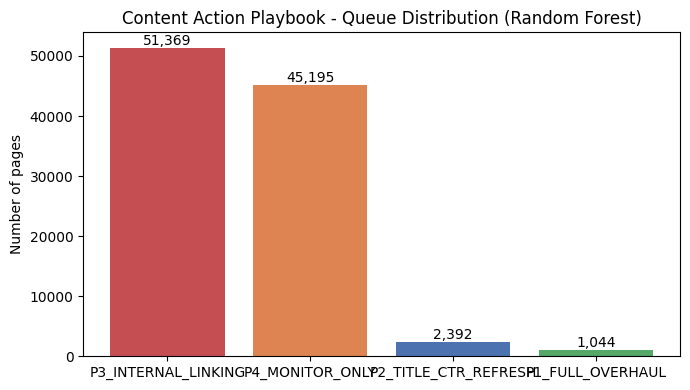

Saved: work/figures/playbook_queue_distribution.png


In [ ]:
# === SECTION 6 CODE - Full Retrain & Action Playbook (Random Forest, primary model) ===
# Re-queries the warehouse using w07_action_playbook.ipynb's EXACT SQL contract (no gsc_data_available
# filter, no AI/word_count columns) so the production queue numbers match the already-validated w07
# output. This is intentionally a SEPARATE dataframe from Section 2-4's ablation dataframe (df).

df_playbook = con.sql(f"""
    WITH feature_window AS (
        SELECT
            p.content_hash_id AS content_id,
            SUM(p.gsc_impressions) AS impressions_30d,
            SUM(p.gsc_clicks) AS clicks_30d,
            CASE
                WHEN SUM(p.gsc_impressions) > 0 THEN (SUM(p.gsc_clicks) * 1.0 / SUM(p.gsc_impressions))
                ELSE 0.0
            END AS ctr_30d,
            CASE
                WHEN SUM(p.gsc_impressions) > 0 THEN LEAST(100.0, (SUM(p.gsc_sum_position) * 1.0 / SUM(p.gsc_impressions)))
                ELSE 100.0
            END AS avg_position,
            COALESCE(DATE_DIFF('day', CAST(d.content_created_date AS DATE), DATE '2026-03-31'), 90) AS content_age_days
        FROM read_parquet('{rel}/fact_content_daily_performance/*/*.parquet') p
        LEFT JOIN read_parquet('{rel}/dim_content.parquet') d ON p.content_hash_id = d.content_hash_id
        WHERE p.report_date BETWEEN '2026-03-01' AND '2026-03-31'
        GROUP BY p.content_hash_id, d.content_created_date
    ),
    label_window AS (
        SELECT
            content_hash_id AS content_id,
            SUM(gsc_impressions) AS future_impressions_30d
        FROM read_parquet('{rel}/fact_content_daily_performance/*/*.parquet')
        WHERE report_date BETWEEN '2026-04-01' AND '2026-04-30'
        GROUP BY content_hash_id
    )
    SELECT
        f.*,
        CASE
            WHEN l.content_id IS NULL THEN 1
            WHEN l.future_impressions_30d < (f.impressions_30d * 0.8) THEN 1
            ELSE 0
        END AS is_declining
    FROM feature_window f
    LEFT JOIN label_window l ON f.content_id = l.content_id
    ORDER BY f.content_id
    LIMIT 100000
""").df()

df_playbook['log_impressions_30d'] = np.log1p(df_playbook['impressions_30d'])

feature_cols_playbook = ['impressions_30d', 'log_impressions_30d', 'ctr_30d', 'avg_position', 'content_age_days']

print(f"df_playbook shape: {df_playbook.shape} (should be ~100,000 rows, matches w07's query contract)")

# Full-dataset retrain on the w07 production feature set + w07 data contract
final_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
final_model.fit(df_playbook[feature_cols_playbook], df_playbook['is_declining'])
df_playbook['opportunity_score'] = final_model.predict_proba(df_playbook[feature_cols_playbook])[:, 1]

def assign_action(row):
    if row['opportunity_score'] >= 0.70 and row['content_age_days'] > 120:
        return 'P1_FULL_OVERHAUL', 'REASON_DECAYED_HIGH_RISK_CONTENT'
    elif row['impressions_30d'] > 1000 and 11 <= row['avg_position'] <= 25:
        return 'P2_TITLE_CTR_REFRESH', 'REASON_STRIKING_DISTANCE_PAGE2'
    elif row['avg_position'] > 30 and row['impressions_30d'] < 100:
        return 'P3_INTERNAL_LINKING', 'REASON_LOW_AUTHORITY_POOR_RANK'
    else:
        return 'P4_MONITOR_ONLY', 'REASON_STABLE_OR_NEW_CONTENT'

tiers = df_playbook.apply(assign_action, axis=1)
df_playbook['action_tier'] = [t[0] for t in tiers]
df_playbook['reason_code'] = [t[1] for t in tiers]
df_playbook['priority_rank_score'] = df_playbook['opportunity_score'] * (np.log1p(df_playbook['impressions_30d']) + 1.0)

df_playbook['no_go_flag'] = np.where(
    (df_playbook['impressions_30d'] > 10000) | (df_playbook['content_age_days'] < 30),
    'REQUIRES_EXECUTIVE_EDITORIAL_REVIEW', 'STANDARD_EDITORIAL_REVIEW'
)

ranked_queue = df_playbook.sort_values('priority_rank_score', ascending=False)

print("\n=== ACTION TIER DISTRIBUTION (Random Forest, production model - w07 data + feature contract) ===")
print(df_playbook['action_tier'].value_counts().to_string())

print("\n=== TOP 5 PRIORITY ITEMS ===")
print(ranked_queue[ranked_queue['action_tier'] != 'P4_MONITOR_ONLY']
      [['content_id','action_tier','reason_code','priority_rank_score','impressions_30d','avg_position']]
      .head(5).to_string(index=False))

# Chart: tier distribution
fig, ax = plt.subplots(figsize=(7, 4))
tier_counts = df_playbook['action_tier'].value_counts()
ax.bar(tier_counts.index, tier_counts.values, color=['#C44E52','#DD8452','#4C72B0','#55A868'])
for i, v in enumerate(tier_counts.values):
    ax.text(i, v + 500, f"{v:,}", ha='center')
ax.set_title("Content Action Playbook - Queue Distribution (Random Forest)")
ax.set_ylabel("Number of pages")
plt.tight_layout()
plt.savefig('work/figures/playbook_queue_distribution.png', dpi=200)
plt.show()
print("Saved: work/figures/playbook_queue_distribution.png")


**The no-go list — never automated:**
- No auto-rewriting or auto-publishing of P1 pages without editorial sign-off.
- No programmatic slug/URL changes.
- No deletion or de-indexing of high-impression pages without business/legal approval.

**Monitoring / retrain triggers:** retrain if rolling test ROC-AUC drops below 0.65, or if monthly impression/position distributions drift more than 20% from this baseline, or if fewer than half of P1/P2 refreshes show positive directional recovery within 60 days.


## 7. Reproducibility & Exports

Every metric and chart in this paper is regenerated by the code cells above — nothing here is a static screenshot. The cell below writes the final action queue, summary metrics, and a monitoring snapshot to `work/outputs/`, and confirms every figure referenced above is present in `work/figures/`.

**Full notebook trail:** `w01_research_question.ipynb` → `w02_ml_task_framing.ipynb` → `w03_data_contract.ipynb` → `w04_baseline_score.ipynb` → `w05_model.ipynb` → `w06_validation_audit.ipynb` → `w07_action_playbook.ipynb` → `capstone.ipynb` (this notebook).

**Dataset release:** `FlyRank/internship-warehouse` on Hugging Face, `fact_content_daily_performance` + `dim_content`, March→April 2026 window.


In [ ]:
# === SECTION 7 CODE - Exports ===
export_cols = ['content_id','action_tier','reason_code','priority_rank_score',
               'opportunity_score','impressions_30d','avg_position','no_go_flag']
ranked_queue[export_cols].head(5000).to_csv('work/outputs/action_queue.csv', index=False)

metrics_payload = {
    "total_analyzed_assets": len(df_playbook),
    "actionable_queue_size": int((df_playbook['action_tier'] != 'P4_MONITOR_ONLY').sum()),
    "tier_distribution": df_playbook['action_tier'].value_counts().to_dict(),
    "no_go_flag_distribution": df_playbook['no_go_flag'].value_counts().to_dict(),
    "primary_model": "RandomForestClassifier (n_estimators=100, max_depth=6) - per Week 7 (ML10) playbook",
    "model_comparison": metrics_df.to_dict(orient='records'),
    "cv_precision_at_50_mean": round(cv_mean, 1),
    "cv_precision_at_50_std": round(cv_std, 1),
    "ai_ablation_permutation_importance_rf": importance.round(6).to_dict(),
    "secondary_check_histgb_traditional_plus_ai": {
        "note": "Tested as a secondary architecture check only; not used in production (see Section 6).",
        "precision_at_50": round(precision_at_k(s_hgb_f, y_test) * 100, 1),
        "roc_auc": round(roc_auc_score(y_test, s_hgb_f), 4)
    },
}
with open('work/outputs/capstone_metrics.json', 'w') as f:
    json.dump(metrics_payload, f, indent=2)

print("=== EXPORT CONFIRMATION ===")
print("work/outputs/action_queue.csv ->", os.path.exists('work/outputs/action_queue.csv'))
print("work/outputs/capstone_metrics.json ->", os.path.exists('work/outputs/capstone_metrics.json'))
for fig_name in ['feature_distributions.png','precision_at_50_comparison.png',
                  'permutation_importance.png','playbook_queue_distribution.png']:
    print(f"work/figures/{fig_name} ->", os.path.exists(f'work/figures/{fig_name}'))


=== EXPORT CONFIRMATION ===
work/outputs/action_queue.csv -> True
work/outputs/capstone_metrics.json -> True
work/figures/feature_distributions.png -> True
work/figures/precision_at_50_comparison.png -> True
work/figures/permutation_importance.png -> True
work/figures/playbook_queue_distribution.png -> True


## 8. Acknowledgments & Data Credit

Built on the **FlyRank ML Internship dataset**. Data courtesy of [flyrank.ai](https://flyrank.ai).

This work is an internship capstone exercise. All findings are observational and decision-support in nature; no client names, domains, URLs, or private queries appear anywhere in this notebook or its outputs.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] All 9 required paper sections present: Title, Abstract, Introduction, Data, Methodology, Results, Limitations, Recommendations, Reproducibility + Acknowledgments/Data Credit
- [ ] Committed to my repo under `work/notebooks/` — then `submission/paper_url.txt` holds the exact deployed URL, one line


# 9. Tell the Story — 5-Minute Demo + Shareable Cuts

## 5-Minute Demo Outline

**0:00–0:45 — Question / real content problem**  
Large content catalogs make monthly manual review difficult. The decision this project supports is: **which pages should a content team review first because their recent search and content signals suggest elevated risk of future impression decline?**

**0:45–1:45 — Method**  
Use March 2026 signals as the feature window and April 2026 impression decline as the future label. Briefly explain the traditional content/search features, the transparent heuristic baseline, the Random Forest, the deterministic 80/20 split, and the leakage audit. Mention that AI-referral features were tested as an ablation rather than treated as a standalone target.

**1:45–2:45 — One chart**  
Show the model-vs-baseline Precision@50 chart. Explain that the same held-out split is used for both: the heuristic baseline reaches **54.0% Precision@50**, while the traditional-feature Random Forest reaches **84.0%**.

**2:45–3:45 — One honest result**  
The traditional-feature Random Forest materially outperformed the baseline on the observed holdout. Adding AI-referral features did not add predictive lift: Precision@50 decreased to **78.0%** and ROC-AUC to **0.6948**. Frame this as an observed result for this dataset/window, not proof that AI-referral traffic never matters.

**3:45–5:00 — Recommendation / action playbook**  
Use the traditional-signal Random Forest as a **review-prioritization tool**, not an automatic content decision-maker. Translate scores into the existing action tiers: **P1 full overhaul, P2 title/CTR refresh, P3 internal linking, P4 monitor-only**. Close by emphasizing that humans make the final editorial decision and that the model does not prove causality or guarantee recovery.

##  Capstone Demo Video

A 5-minute voice-over presentation of the capstone research question, methodology, key result, and recommended action playbook.

**Video:** `media/capstone-demo.mp4`  

## Social Post

I built a content-decay early-warning and prioritization model using real FlyRank search and content data. I compared a transparent heuristic baseline with a leakage-checked Random Forest using historical search/content signals, then tested whether sparse AI-assistant referral features added predictive value. The traditional-feature model reached **84% Precision@50 vs. 54% for the baseline** on the same held-out split, while the AI-feature ablation did not improve the primary model. The key takeaway was less about producing a score and more about turning that score into a practical, human-reviewed content action queue.

## Employer-Facing 3-Sentence Summary

I built a content-decay early-warning and prioritization model using real FlyRank search-performance and content data, with a leakage-checked validation workflow and a transparent baseline for comparison. The traditional-feature Random Forest achieved **84.0% Precision@50**, compared with **54.0%** for the heuristic baseline on the same held-out split, while adding sparse AI-referral features did not provide incremental lift in the primary model. I translated the predictions into ranked editorial action tiers so the model could support practical content-review decisions rather than simply producing a predictive score.

**LinkedIn post:** https://lnkd.in/p/dEj7BaEP
